# Görselleştirme ve Veri Keşfi (ML-11)

Bu defter, `scripts/make_visualizations.py` ile üretilen **read-only** analiz
çıktılarının yürütülmüş kaydıdır. Amaç: "bazı arıza türleri neden hâlâ zayıf
tespit ediliyor?" sorusuna görsel kanıt sunmak — model değil, veri.

Disiplin kuralları:
1. **Blind holdout (131 SEAD uçuşu) hiçbir figürde/istatistikte yok** —
   aşağıda hash doğrulamasıyla assert edilir; `tests/test_ml11_viz.py` de aynı
   kontrolü yapar.
2. Hiçbir model/eşik/split/scaler/CUSUM artifact'ı değişmedi (read-only faz).
3. Tek-feature AUC'ler **keşif** amaçlıdır; oradan seçilen feature'larla aynı
   veri üzerinde sonuç raporlamak overfitting olur — adaylar ancak yeni bir
   Gate turuyla değerlendirilir.

Not (dışa dönük kullanım): figür başlıkları faz numarası değil içerik adı
taşır ("Sınıf Dağılımı", "Feature-Kategori Ayrıştırma", ...).

In [1]:
import hashlib
import json
import sys
from pathlib import Path

import pandas as pd
from IPython.display import Image, display

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT))
VIZ = ROOT / "artifacts/viz"
SPLIT_PATH = ROOT / "data/gold/ml_features/split_manifest.json"

manifests = {s: json.loads((VIZ / s / "viz_manifest.json").read_text(encoding="utf-8"))
             for s in ("alfa", "uav_attack", "uav_sead")}
pd.DataFrame([
    {"dataset": s,
     "development_ucus": m["development_flights"],
     "blind_holdout_ucus": m["blind_holdout_flights"],
     "holdout_okundu_mu": m["blind_holdout_read"],
     "figur_ve_csv_sayisi": len(m["files"]),
     "seed": m["seed"]}
    for s, m in manifests.items()
])

,dataset,development_ucus,blind_holdout_ucus,holdout_okundu_mu,figur_ve_csv_sayisi,seed
0,alfa,54,0,False,29,42
1,uav_attack,19,0,False,16,42
2,uav_sead,480,131,False,42,42


## Holdout izolasyon doğrulaması

Koşuda kullanılan development uçuş kümesinin hash'i, split manifest'ten
bağımsız yeniden türetilen (tüm uçuşlar − final_holdout) kümenin hash'iyle
birebir aynı olmalı.

In [2]:
split_manifest = json.loads(SPLIT_PATH.read_text(encoding="utf-8"))
for source, m in manifests.items():
    cfg = split_manifest["sources"][source]
    holdout = set(cfg["splits"]["split_00"].get("final_holdout", []))
    expected_dev = sorted(set(cfg["flight_labels"]) - holdout)
    expected_hash = hashlib.sha256("\n".join(expected_dev).encode()).hexdigest()
    assert m["development_source_ids_sha256"] == expected_hash, source
    assert m["blind_holdout_read"] is False
    assert not holdout & set(expected_dev)
    print(f"{source}: OK — {len(expected_dev)} development ucus, "
          f"{len(holdout)} holdout ucus hicbir figurde yok")

alfa: OK — 54 development ucus, 0 holdout ucus hicbir figurde yok
uav_attack: OK — 19 development ucus, 0 holdout ucus hicbir figurde yok
uav_sead: OK — 480 development ucus, 131 holdout ucus hicbir figurde yok


## Bölüm 1 — Veri karnesi

Sınıf dengesizliği, SEAD normal sınıfının oturum yapısı (heterojen-normal
bulgusunun görsel kanıtı) ve feature×etiket doluluk haritası
("bu kategoride bu sinyal fiziksel olarak yok" haritası).

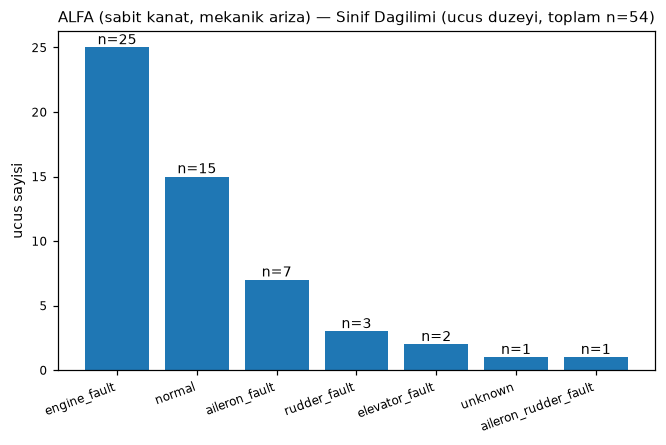

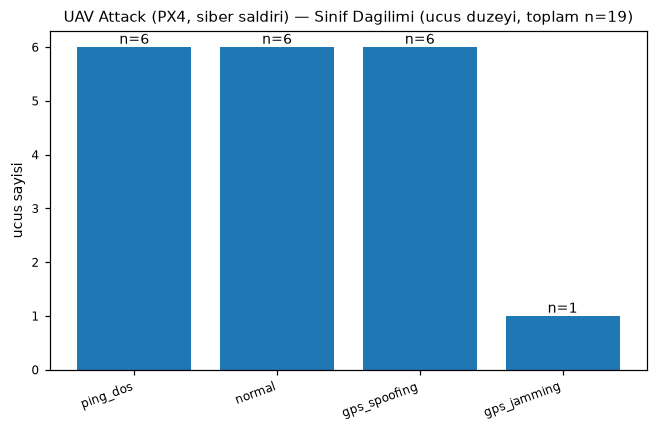

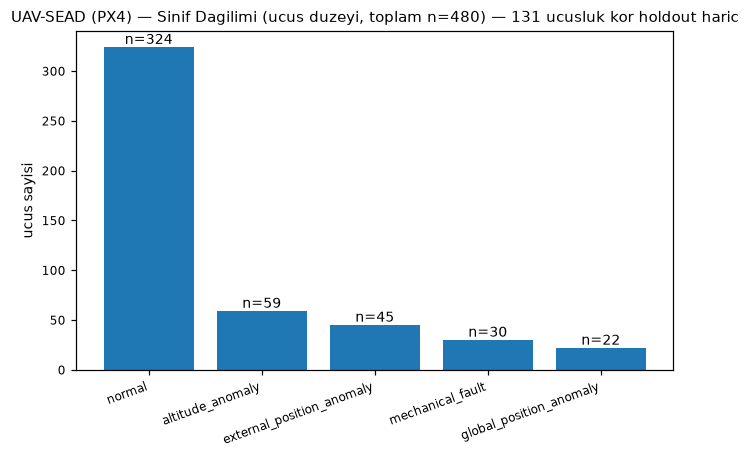

In [3]:
for source in ("alfa", "uav_attack", "uav_sead"):
    display(Image(filename=VIZ / source / "s1_portfolio/class_counts.png"))

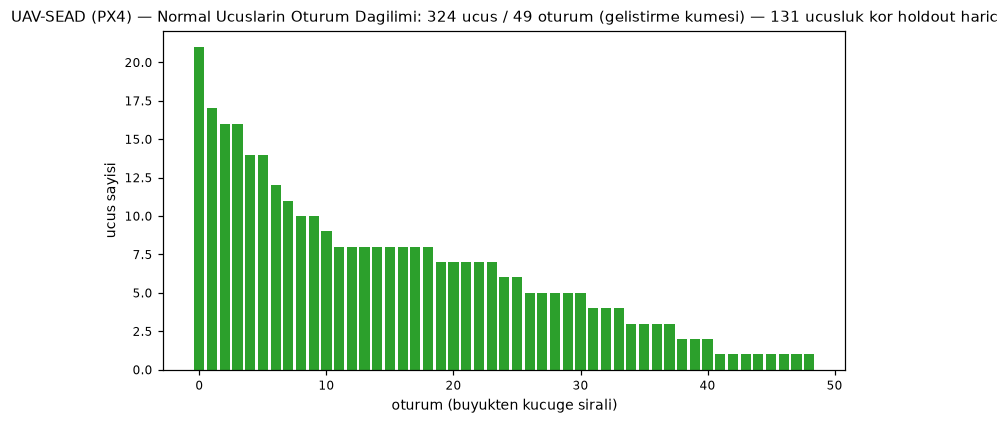

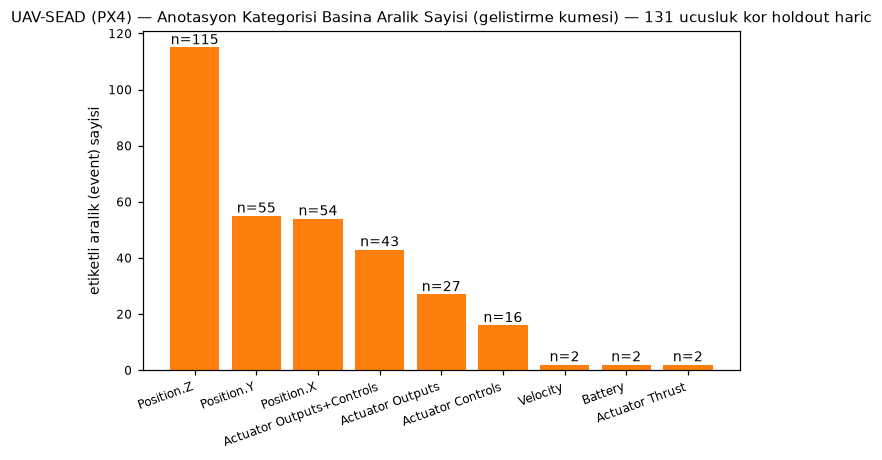

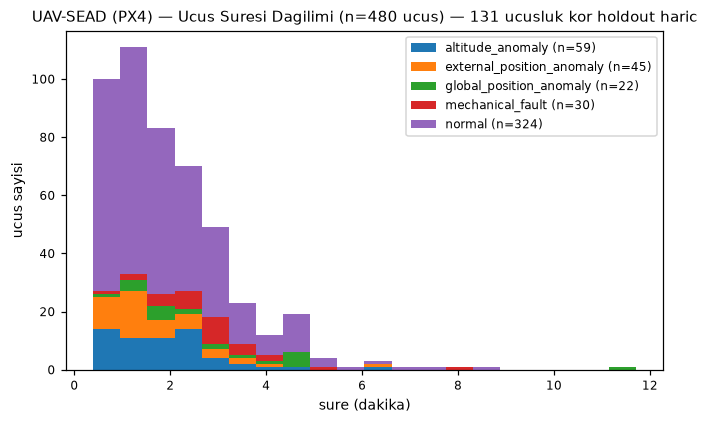

In [4]:
display(Image(filename=VIZ / "uav_sead/s1_portfolio/session_histogram.png"))
display(Image(filename=VIZ / "uav_sead/s1_portfolio/annotation_event_counts.png"))
display(Image(filename=VIZ / "uav_sead/s1_portfolio/flight_duration_hist.png"))

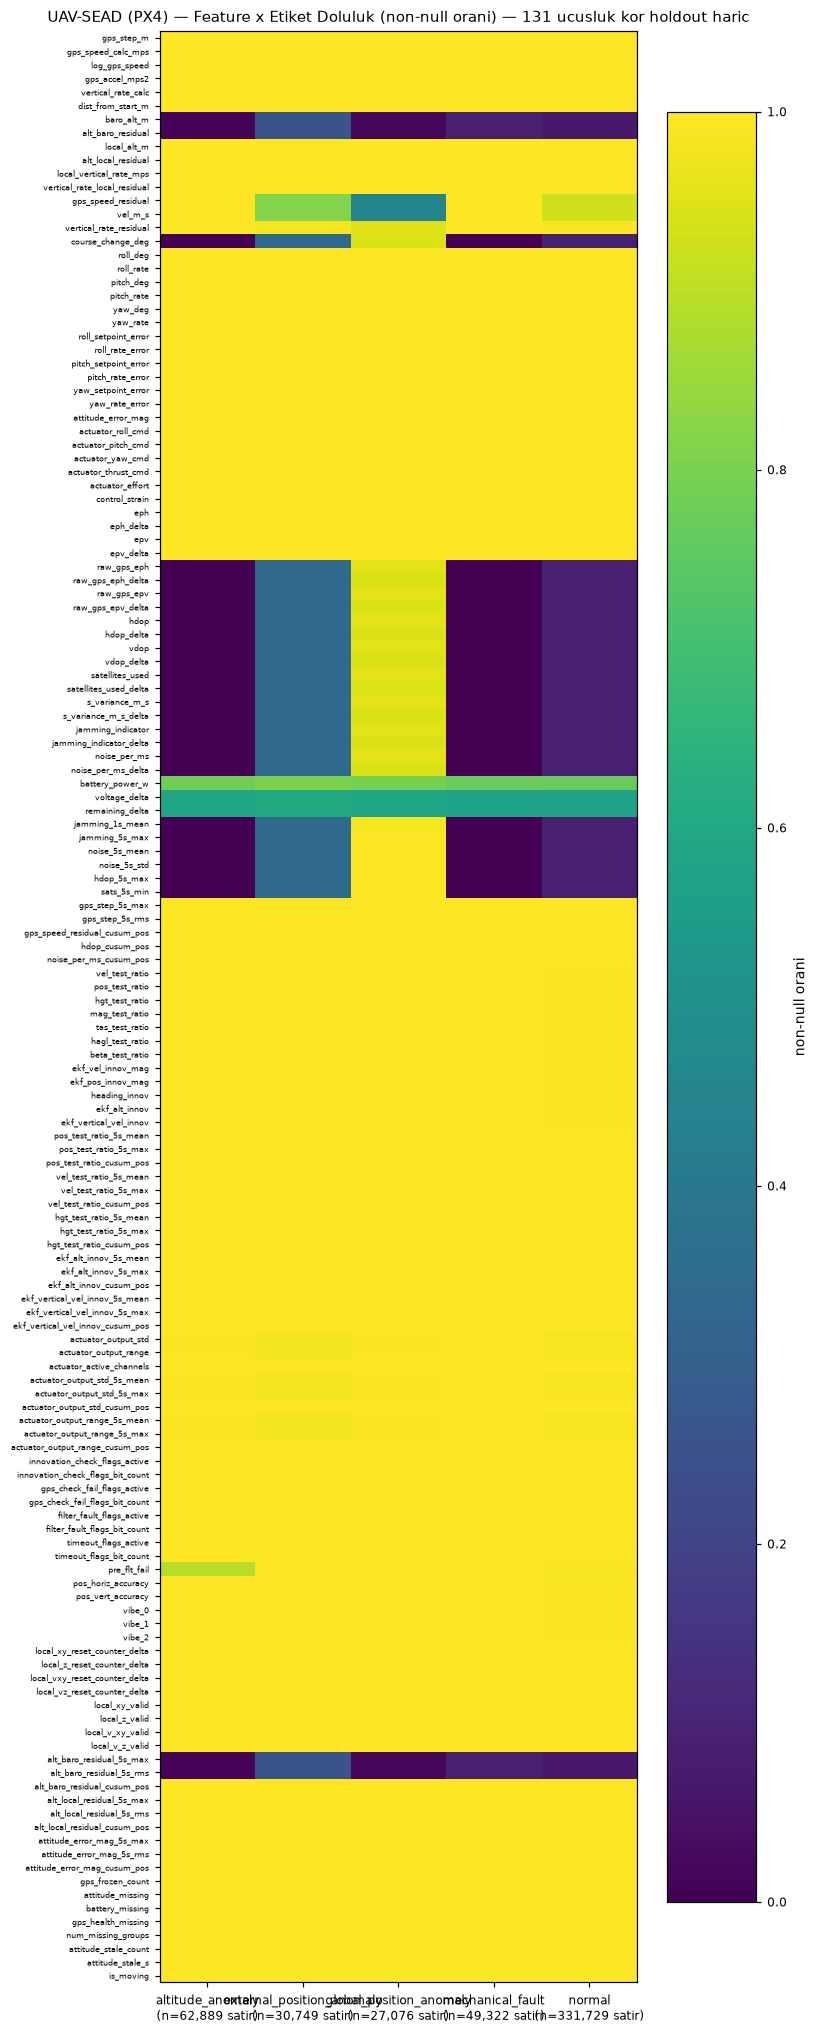

In [5]:
display(Image(filename=VIZ / "uav_sead/s1_portfolio/completeness_heatmap.png"))

## Bölüm 2 — Embedding projeksiyonları (PCA + t-SNE)

Girdi: frozen scaler'dan geçmiş satır vektörleri (yalnız görselleştirme için
±10 IQR kırpma; hiçbir skor hesabına girmez). Uçuş başına ≤200 satır,
deterministik seed=42. **t-SNE yalnız lokal komşuluğu korur; kümeler arası
mesafe/boyut yorumlanmaz.**

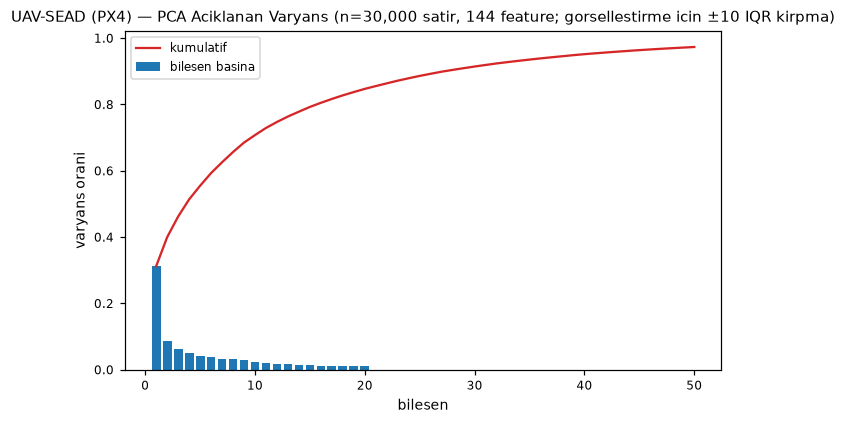

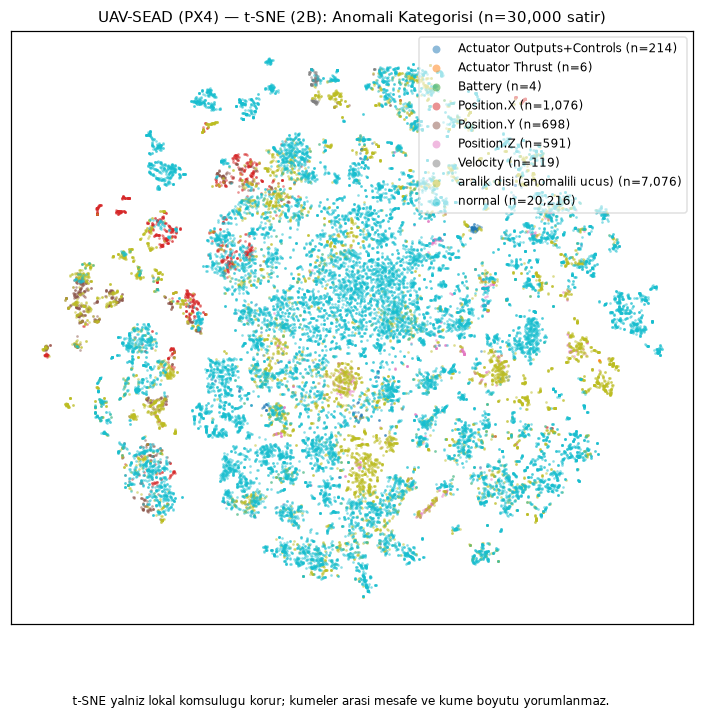

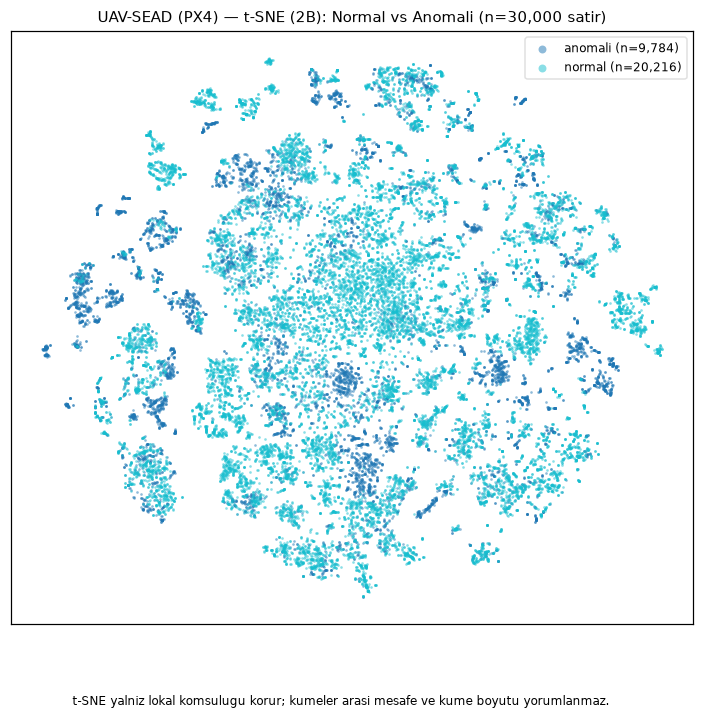

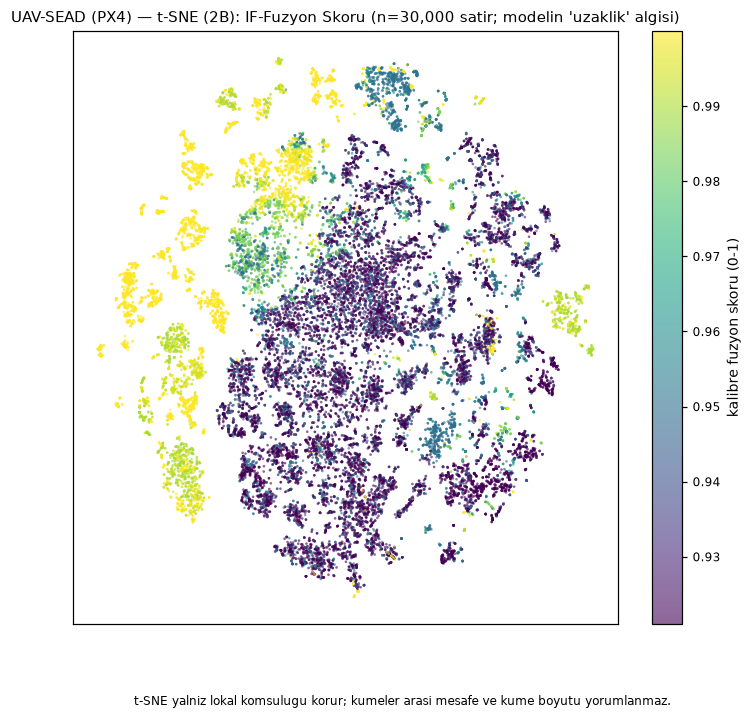

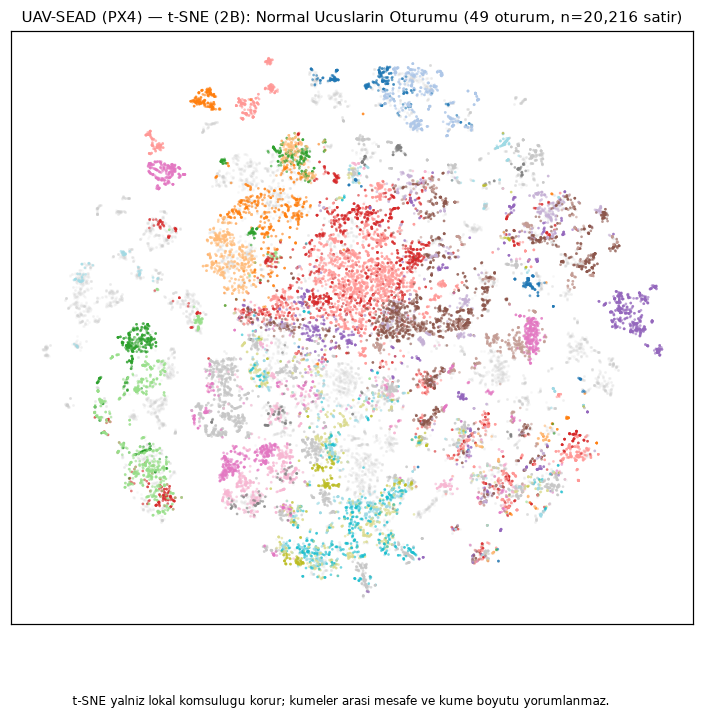

In [6]:
for name in ("pca_variance", "tsne_label", "tsne_binary", "tsne_fusion", "tsne_session"):
    display(Image(filename=VIZ / f"uav_sead/s2_embeddings/{name}.png"))

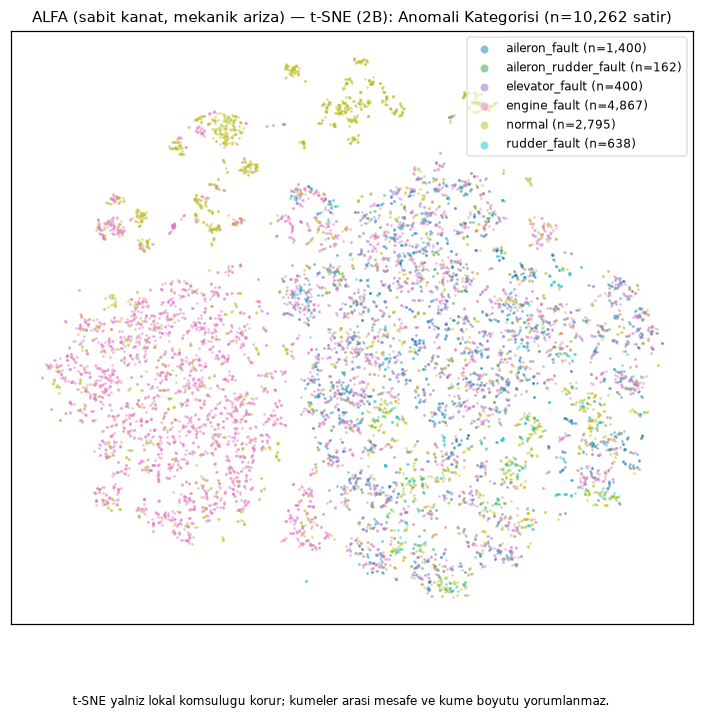

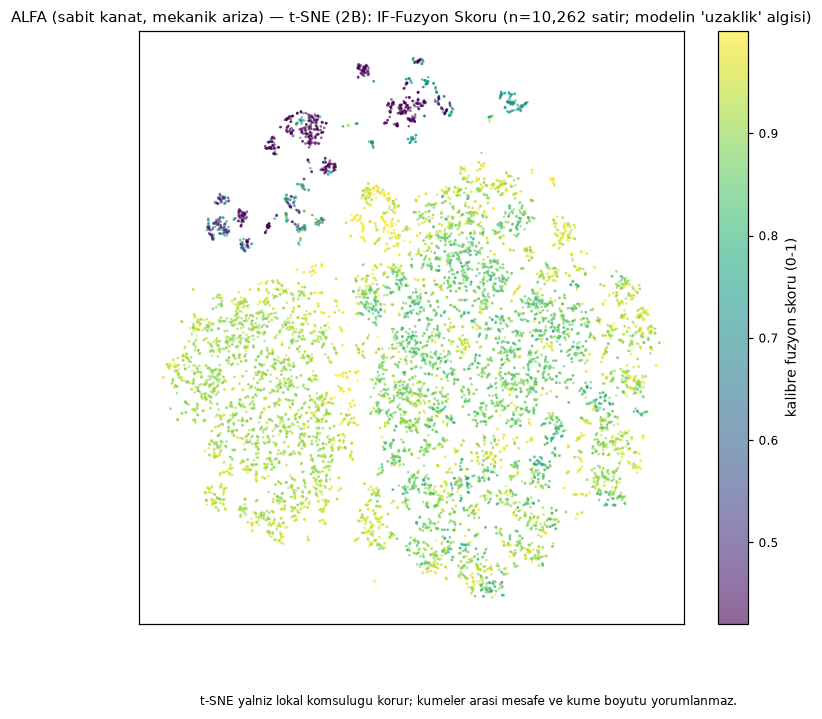

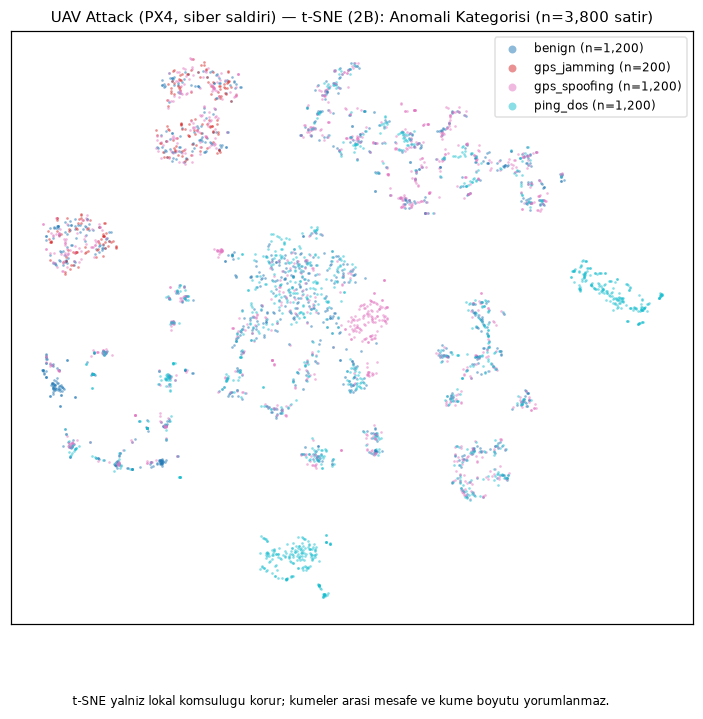

In [7]:
for name in ("tsne_label", "tsne_fusion"):
    display(Image(filename=VIZ / f"alfa/s2_embeddings/{name}.png"))
display(Image(filename=VIZ / "uav_attack/s2_embeddings/tsne_label.png"))

## Bölüm 3 — Feature analitikleri (ANA ÇIKTI)

Her hücre: o feature'ın o kategoriyi normal satırlardan tek başına ne kadar
ayırdığı (Mann-Whitney AUC; 0.5 = ayrışma yok). Yanında seyrek-imza
göstergesi: log2(kategori q99 / normal q99), |x| üzerinden.

Okuma anahtarı:
- Bir kategori **hiçbir** feature'da ayrışmıyorsa → veri/kapsam sorunu.
- Güçlü feature var ama füzyon skoru zayıfsa → füzyon/model sorunu
  (gerçek feature-engineering adayı).

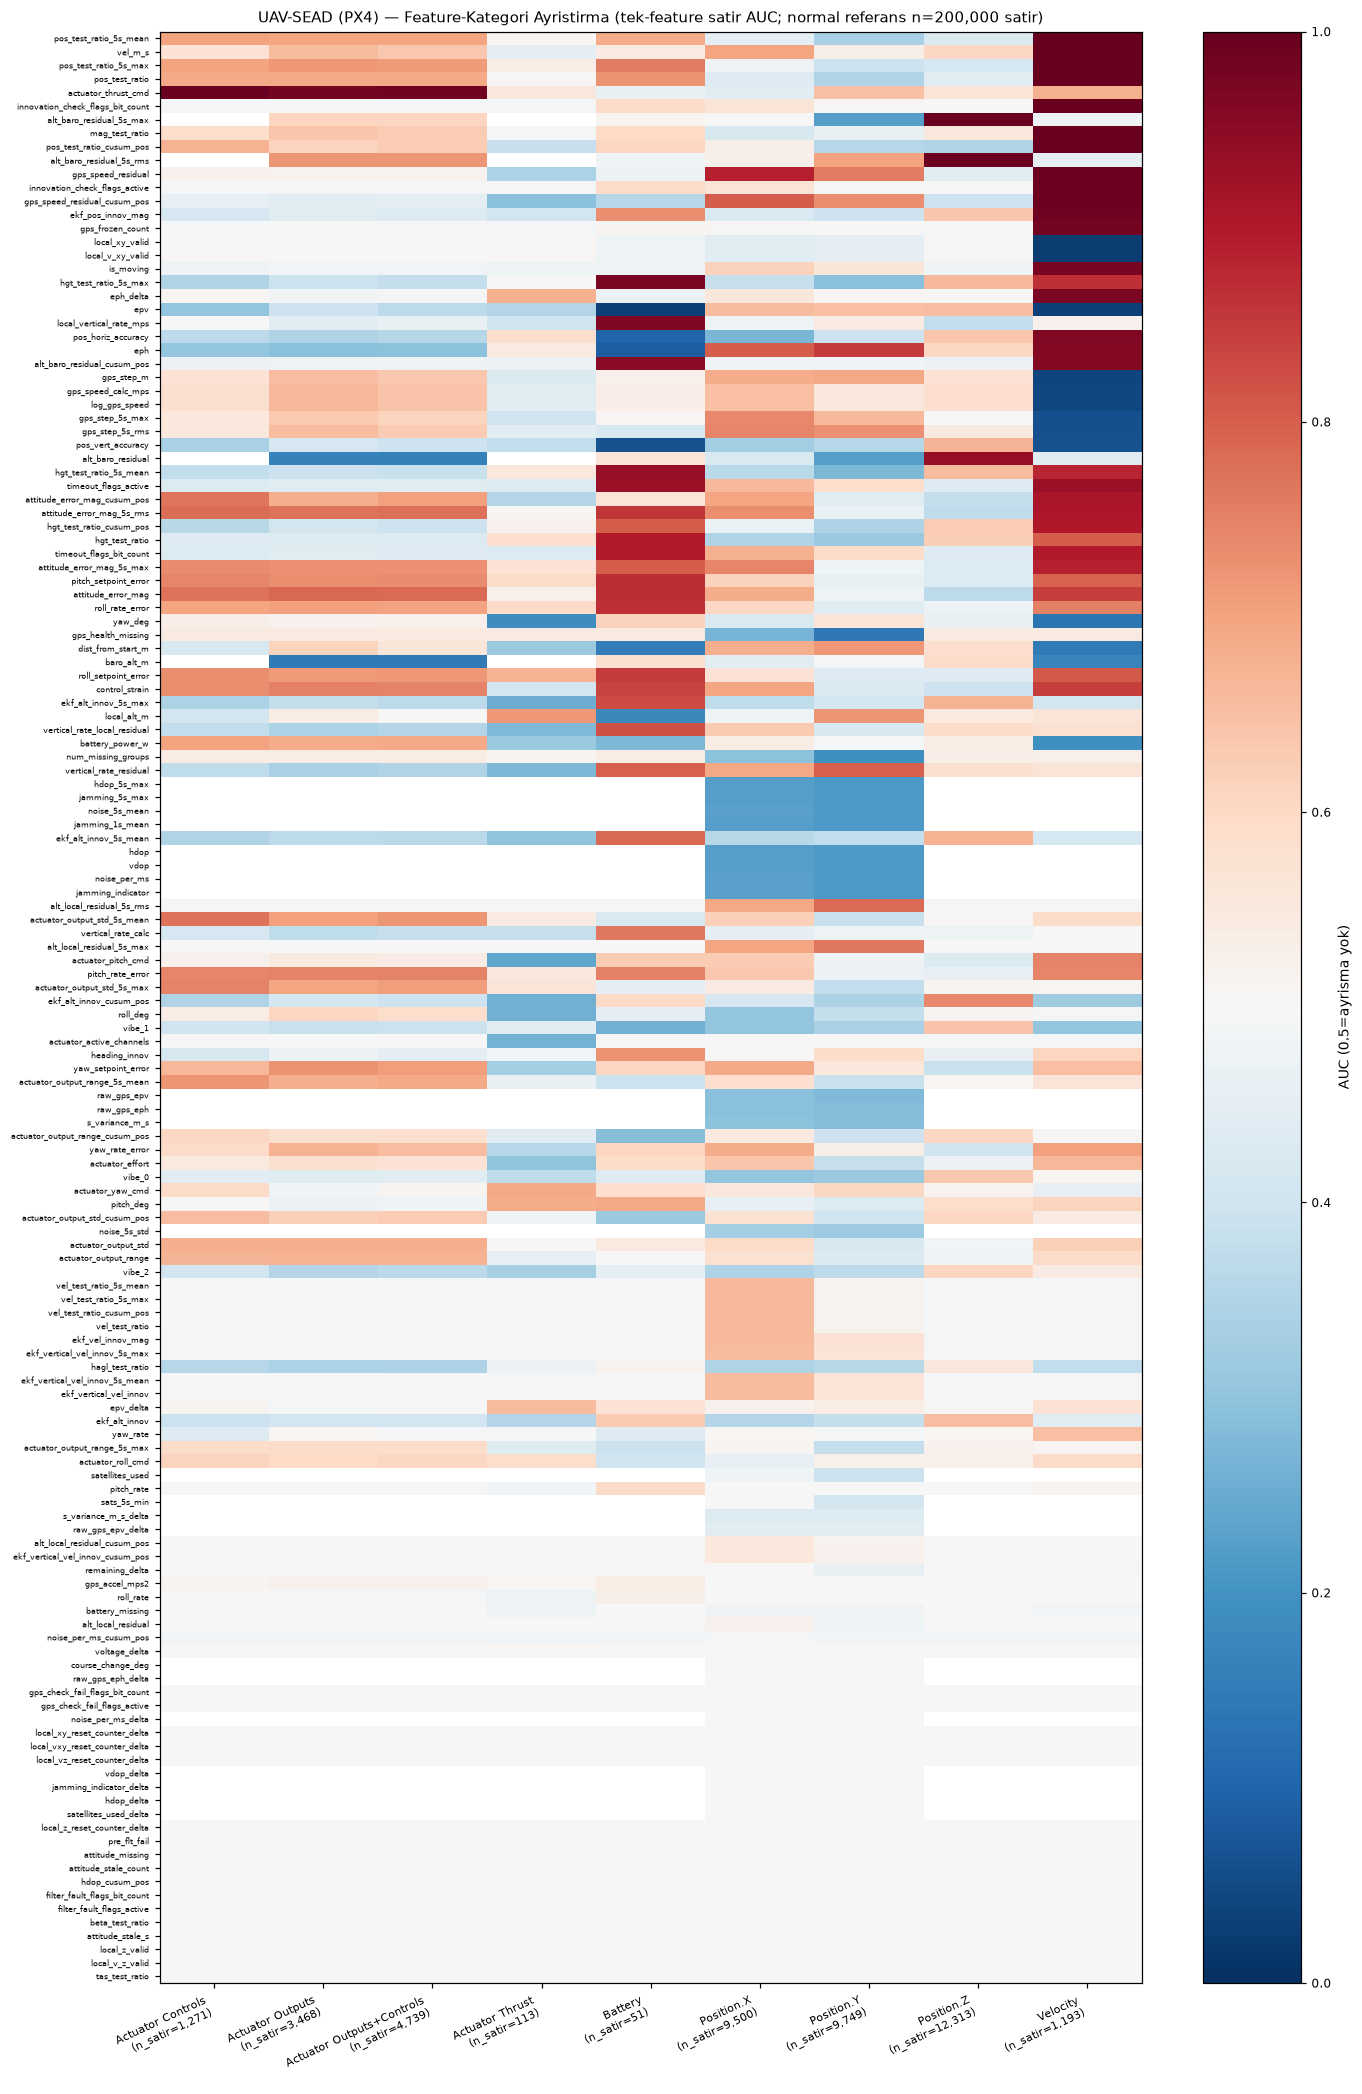

In [8]:
display(Image(filename=VIZ / "uav_sead/s3_features/feature_auc_heatmap.png"))

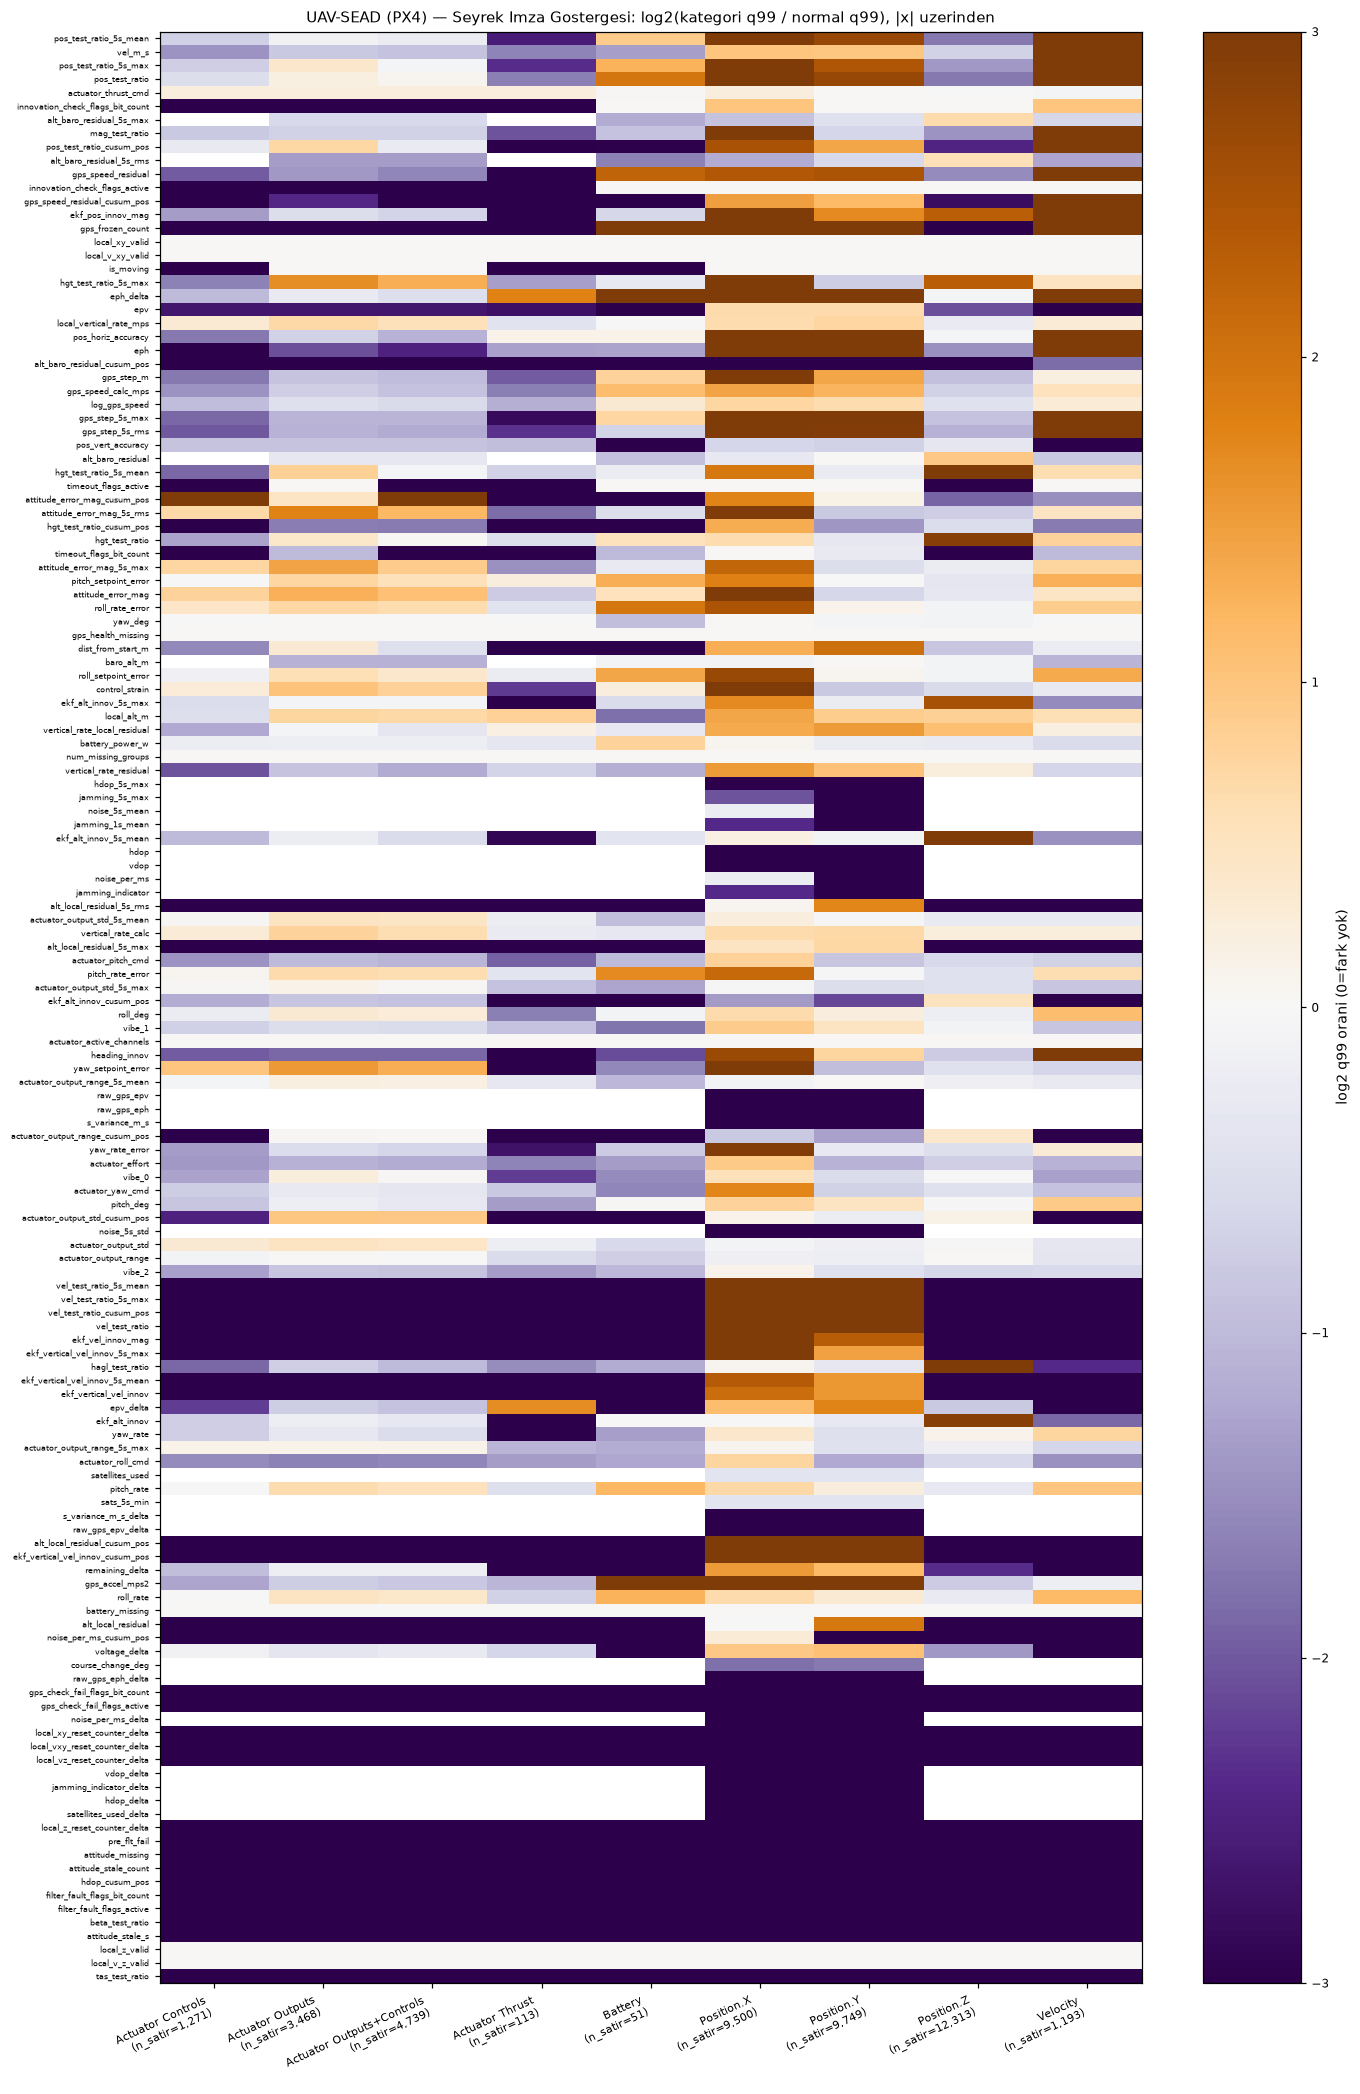

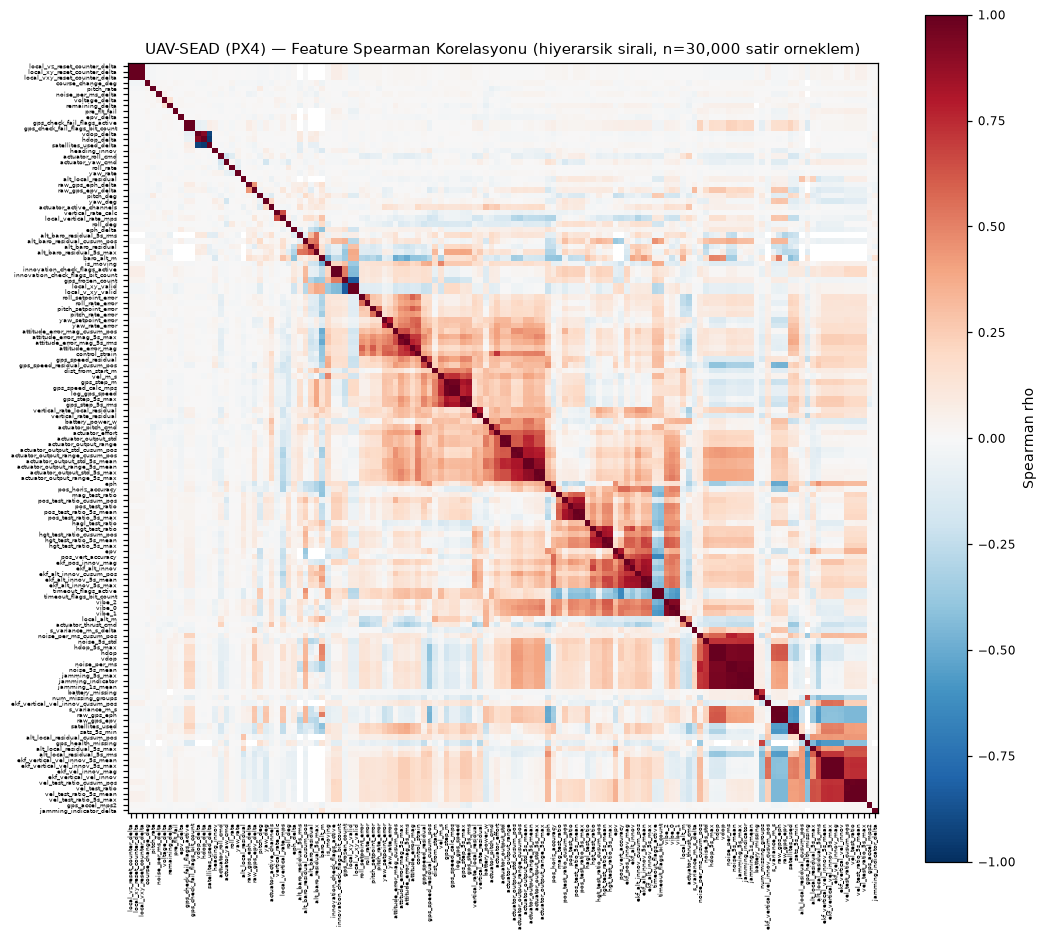

In [9]:
display(Image(filename=VIZ / "uav_sead/s3_features/feature_q99_heatmap.png"))
display(Image(filename=VIZ / "uav_sead/s3_features/spearman_heatmap.png"))

In [10]:
auc = pd.read_csv(VIZ / "uav_sead/s3_features/feature_auc_matrix.csv")
weak = ["Actuator Outputs+Controls", "Position.Z", "Actuator Thrust"]
for category in weak:
    sub = (auc[auc["category"] == category]
           .sort_values("separation", ascending=False)
           [["feature", "auc", "separation", "q99_abs_ratio", "n_pos"]].head(8))
    print(f"=== {category} — en iyi 8 tek-feature ayristirici ===")
    display(sub.reset_index(drop=True))

=== Actuator Outputs+Controls — en iyi 8 tek-feature ayristirici ===


,feature,auc,separation,q99_abs_ratio,n_pos
0,actuator_thrust_cmd,0.983355,0.983355,1.161698,4739
1,baro_alt_m,0.147249,0.852751,0.462167,45
2,alt_baro_residual,0.163266,0.836734,0.797683,45
3,attitude_error_mag,0.782736,0.782736,2.084775,4739
4,attitude_error_mag_5s_rms,0.774761,0.774761,2.258213,4739
5,control_strain,0.748021,0.748021,1.761324,4739
6,pitch_rate_error,0.746512,0.746512,1.542468,4739
7,pitch_setpoint_error,0.736138,0.736138,1.471559,4739


=== Position.Z — en iyi 8 tek-feature ayristirici ===


,feature,auc,separation,q99_abs_ratio,n_pos
0,alt_baro_residual_5s_max,0.995532,0.995532,1.582303,33
1,alt_baro_residual_5s_rms,0.992136,0.992136,1.489177,33
2,alt_baro_residual,0.936218,0.936218,1.932675,33
3,ekf_alt_innov_cusum_pos,0.741366,0.741366,1.418218,12313
4,ekf_alt_innov_5s_max,0.674877,0.674877,5.749365,12313
5,ekf_alt_innov_5s_mean,0.672754,0.672754,11.483713,12313
6,pos_vert_accuracy,0.669499,0.669499,0.795870,12293
7,hgt_test_ratio_5s_max,0.663363,0.663363,4.975689,12313


=== Actuator Thrust — en iyi 8 tek-feature ayristirici ===


,feature,auc,separation,q99_abs_ratio,n_pos
0,yaw_deg,0.188781,0.811219,0.993317,113
1,actuator_pitch_cmd,0.240195,0.759805,0.259902,113
2,ekf_alt_innov_5s_max,0.253096,0.746904,0.083692,113
3,ekf_alt_innov_cusum_pos,0.258395,0.741605,0.000000,113
4,roll_deg,0.260237,0.739763,0.316791,113
5,actuator_active_channels,0.264931,0.735069,1.000000,113
6,vertical_rate_residual,0.276080,0.723920,0.629979,113
7,vertical_rate_local_residual,0.279158,0.720842,1.127044,113


=== ALFA rudder_fault — en iyi 6 ===


,feature,auc,separation,q99_abs_ratio,n_pos
0,path_dev_mag,0.068601,0.931399,0.497195,653
1,roll_spec_energy_5s,0.914559,0.914559,2.321999,970
2,pitch_spec_energy_5s,0.909236,0.909236,2.960972,970
3,specific_energy,0.897183,0.897183,0.961114,979
4,dist_from_start_m,0.892120,0.892120,1.199052,979
5,throttle,0.886375,0.886375,1.000000,979


=== ALFA engine_fault — en iyi 6 ===


,feature,auc,separation,q99_abs_ratio,n_pos
0,wp_dist,0.912965,0.912965,1.148213,11264
1,abs_yaw_error,0.102656,0.897344,0.917792,11264
2,yaw_error_5s_rms,0.105929,0.894071,0.924513,11321
3,roll_error_2s_std,0.863579,0.863579,0.871203,11257
4,airspeed_error_5s_std,0.860493,0.860493,2.379046,11293
5,roll_error_5s_std,0.855314,0.855314,0.888190,11293


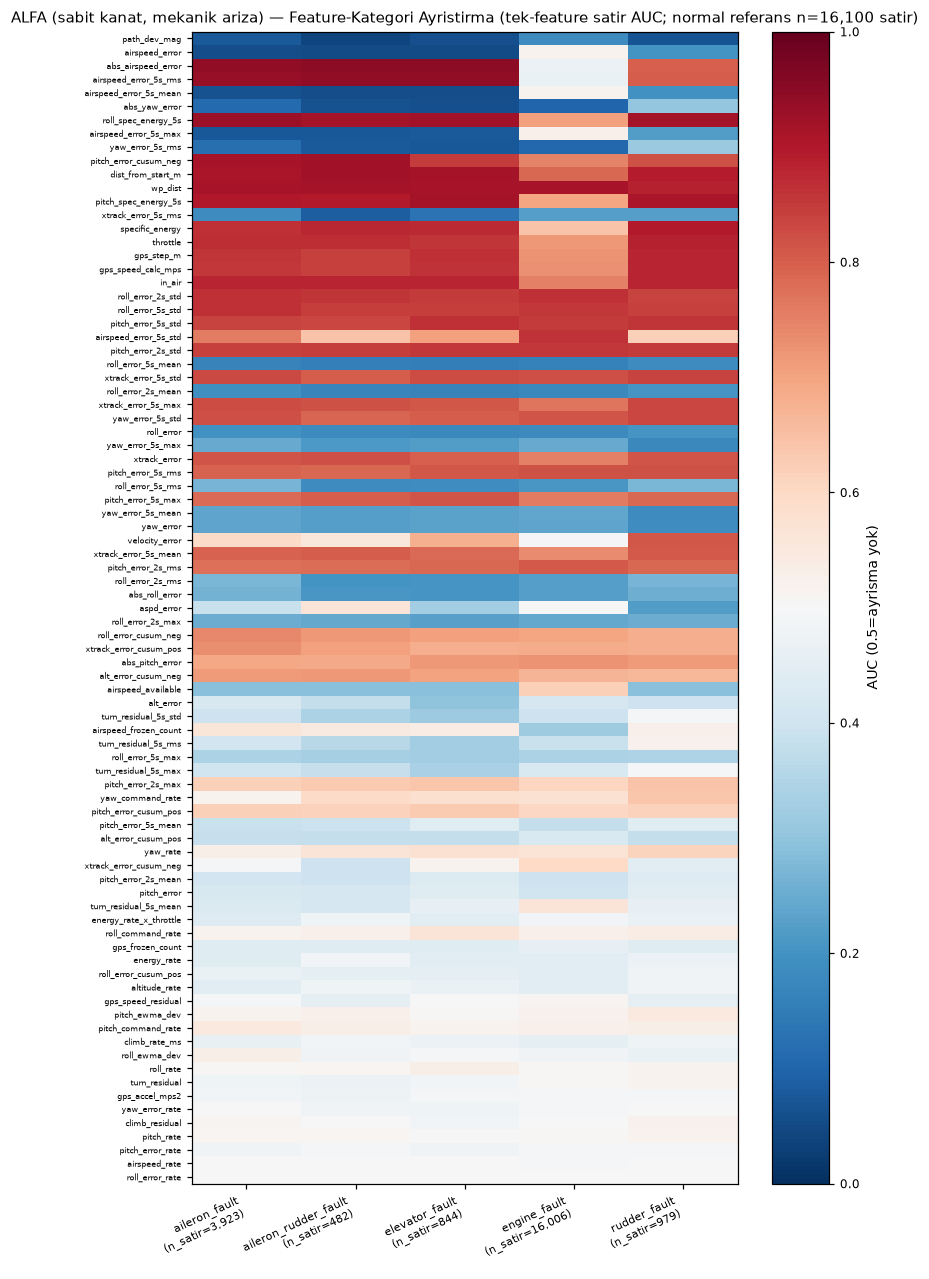

In [11]:
alfa_auc = pd.read_csv(VIZ / "alfa/s3_features/feature_auc_matrix.csv")
for category in ("rudder_fault", "engine_fault"):
    sub = (alfa_auc[alfa_auc["category"] == category]
           .sort_values("separation", ascending=False)
           [["feature", "auc", "separation", "q99_abs_ratio", "n_pos"]].head(6))
    print(f"=== ALFA {category} — en iyi 6 ===")
    display(sub.reset_index(drop=True))
display(Image(filename=VIZ / "alfa/s3_features/feature_auc_heatmap.png"))

In [12]:
redundant = {s: len(pd.read_csv(VIZ / s / "s3_features/redundant_pairs.csv"))
             for s in ("alfa", "uav_attack", "uav_sead")}
print("|rho|>0.9 gereksiz cift sayisi:", redundant)

|rho|>0.9 gereksiz cift sayisi: {'alfa': 10, 'uav_attack': 103, 'uav_sead': 69}


## Bölüm 4 — Model tanılama

Mevcut artifact modeller (SEAD: ML-9 frozen 5-seed IF-füzyon; ALFA: paketlenmiş
split_00 LSTM-AE) — **eğitim yok**. Karar matrisi başlığında yazdığı gibi model
sınıf tahmin etmez; ikili alarm kararının tür bazlı karşılığı verilir.

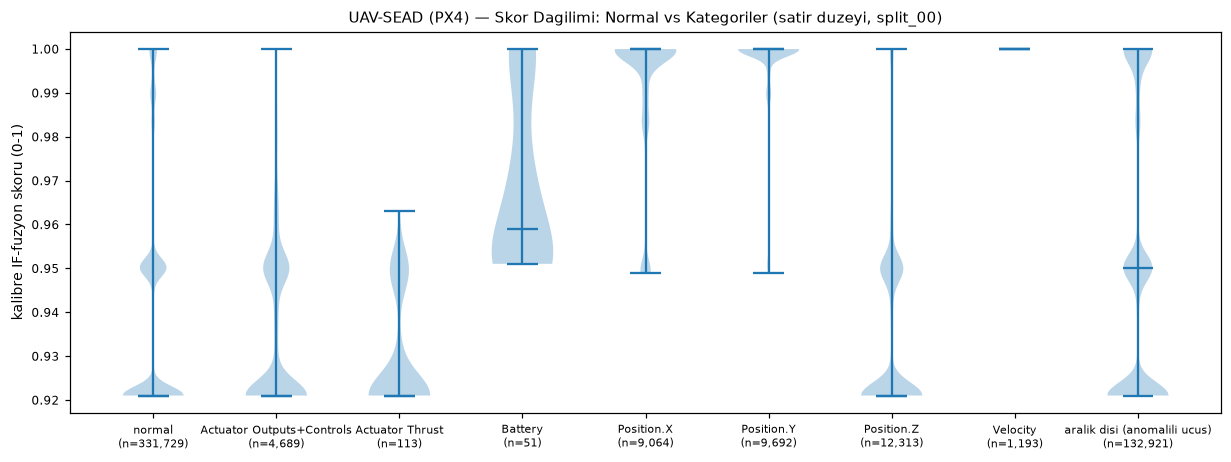

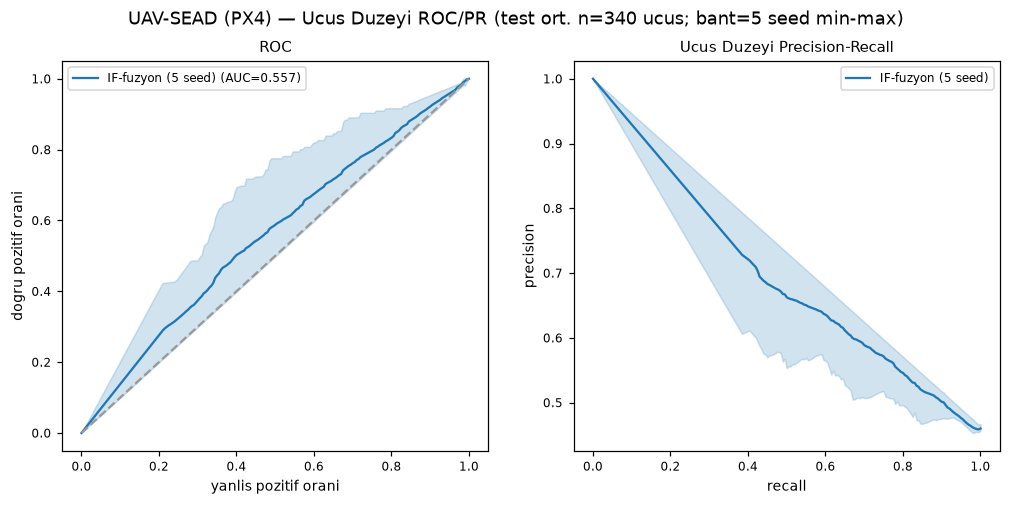

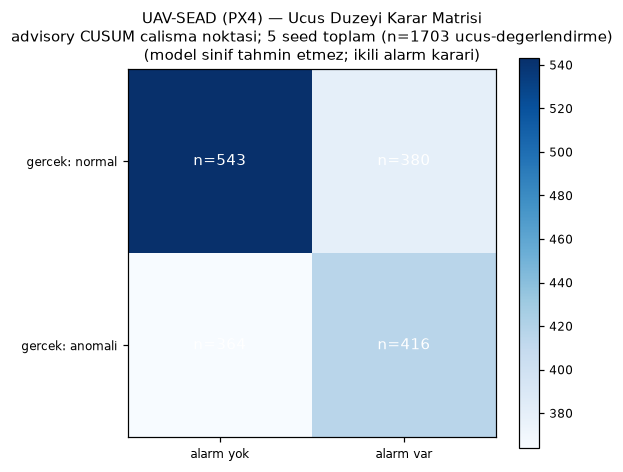

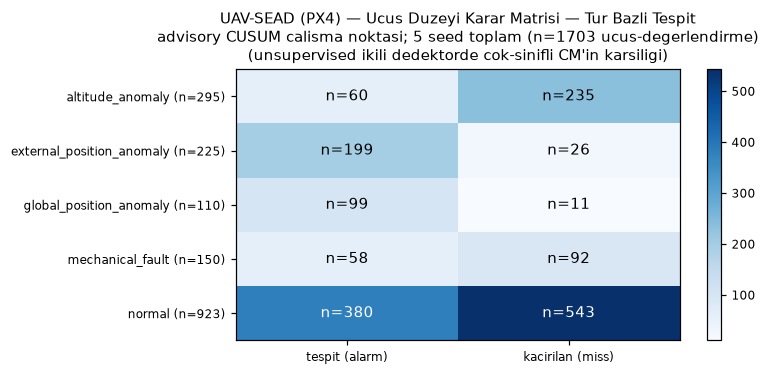

In [13]:
for name in ("score_violin", "roc_pr_flight", "sead_confusion_binary", "sead_confusion_by_type"):
    display(Image(filename=VIZ / f"uav_sead/s4_model/{name}.png"))

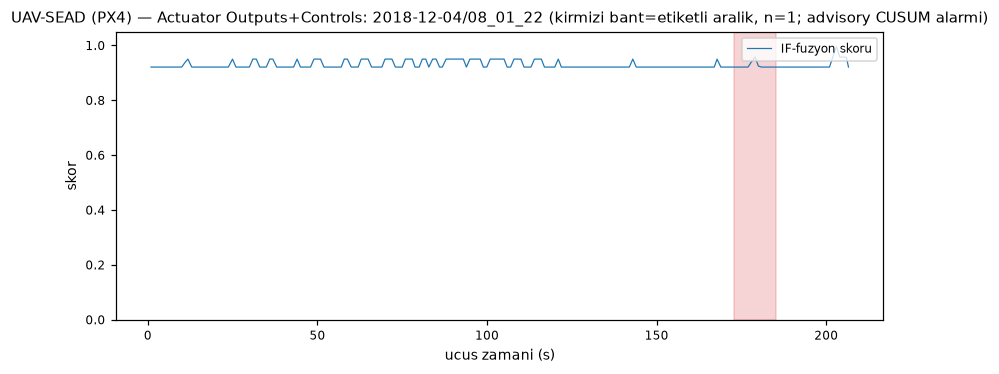

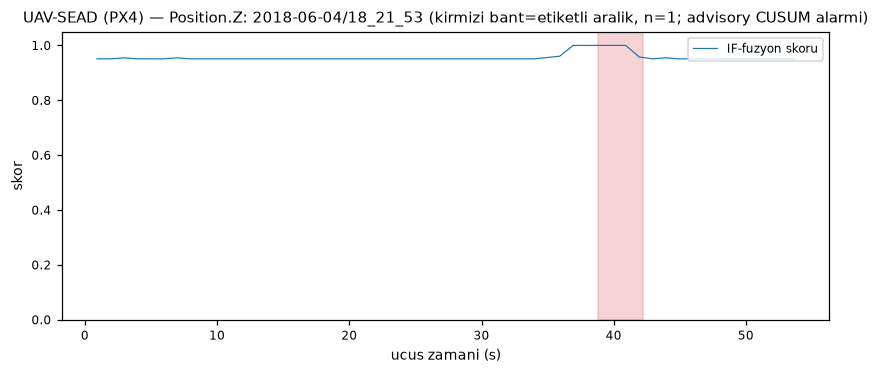

In [14]:
display(Image(filename=VIZ / "uav_sead/s4_model/timeseries_Actuator_Outputs_Controls_2018-12-04__08_01_22.png"))
display(Image(filename=VIZ / "uav_sead/s4_model/timeseries_Position_Z_2018-06-04__18_21_53.png"))

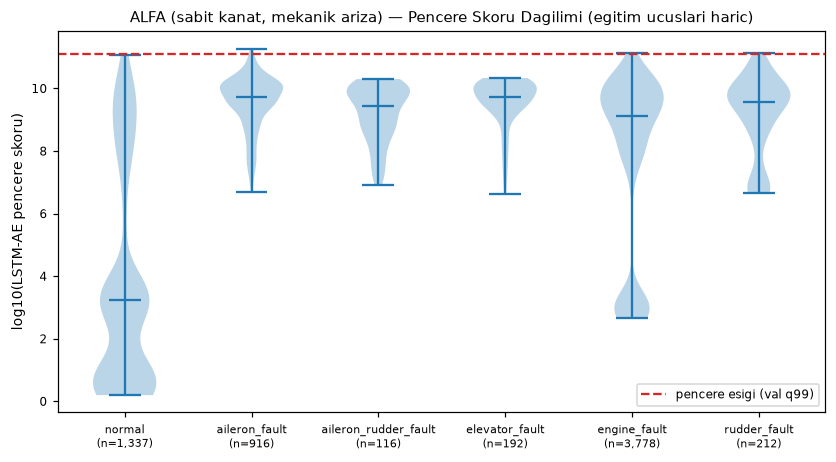

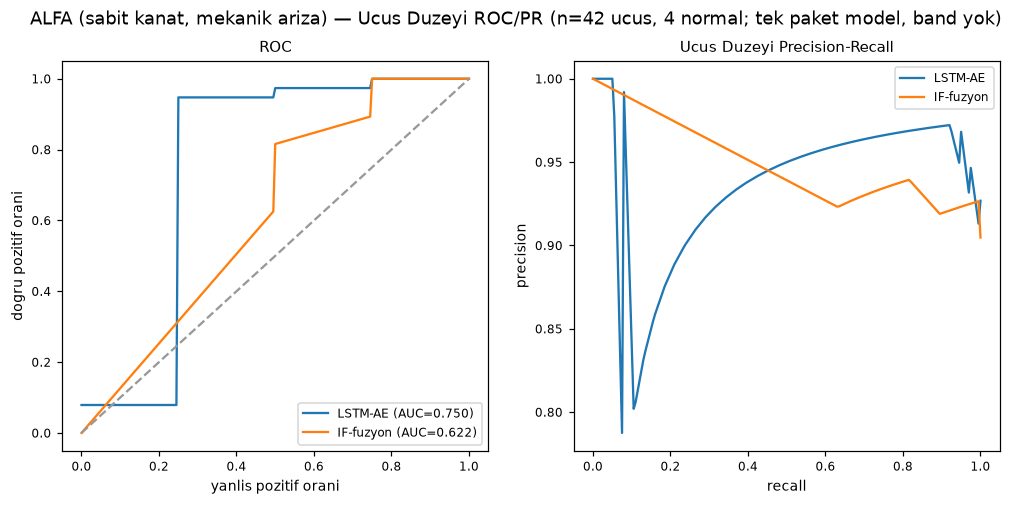

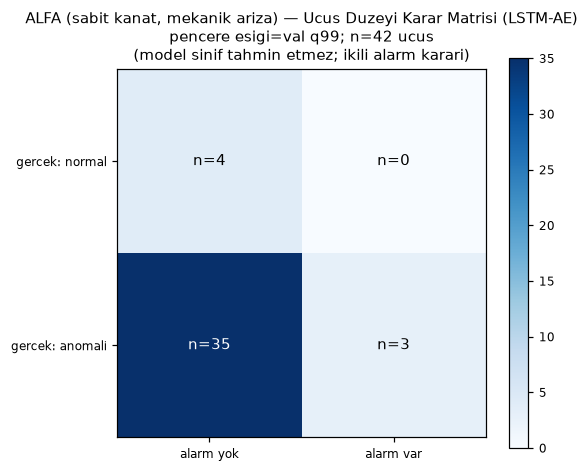

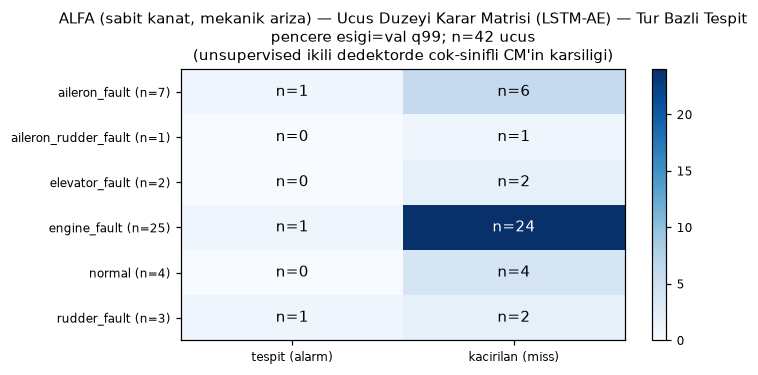

In [15]:
for name in ("score_violin", "roc_pr_flight", "alfa_confusion_binary", "alfa_confusion_by_type"):
    display(Image(filename=VIZ / f"alfa/s4_model/{name}.png"))

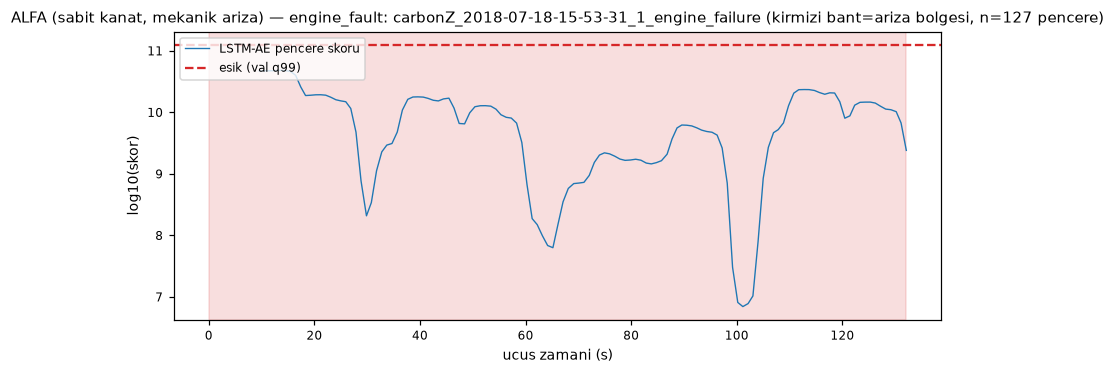

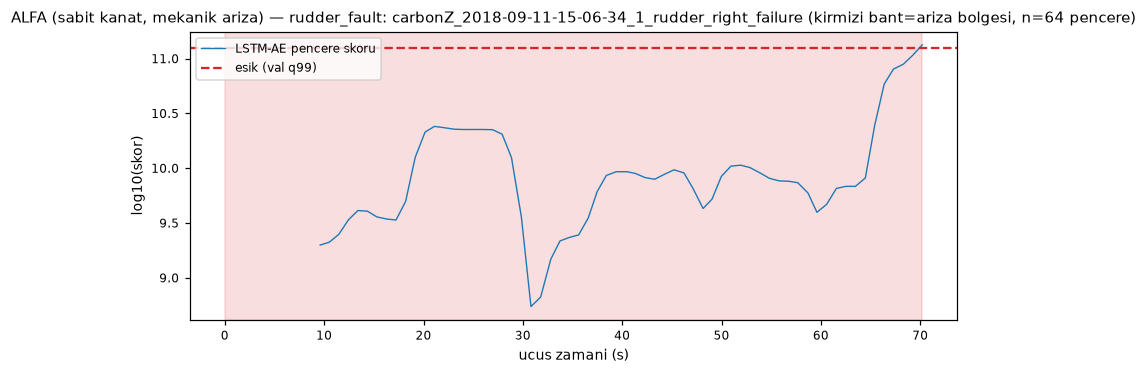

In [16]:
import glob
one = sorted(glob.glob(str(VIZ / "alfa/s4_model/timeseries_engine_fault_*.png")))[0]
display(Image(filename=one))
one = sorted(glob.glob(str(VIZ / "alfa/s4_model/timeseries_rudder_fault_*.png")))[0]
display(Image(filename=one))

## Bölüm 5 — Eğitim izi altyapısı (kalıcı kural)

`train_lstm_autoencoder` artık epoch başına train/val loss geçmişi döndürür ve
`src/ml/training_log.py::write_training_log` bunu
`artifacts/training_logs/<source>/<model>/<run_id>/loss.csv` + `loss.png`
olarak yazar. Paketleme scriptleri (`package_ml6_lstm.py`,
`package_ml8a_sead_lstm.py`) bu çağrıyı içerir: **bundan sonra eğitilen her
model iz bırakır.** (Bu fazda model eğitilmediği için mevcut artifact'lar
değişmedi; mekanizma aşağıda sentetik bir geçmişle gösterilir, çıktı geçici
dizine yazılır.)

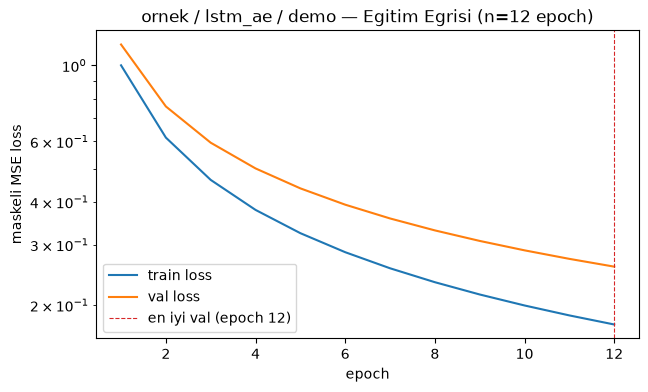

   epoch  train_loss  val_loss
0      1    1.000000  1.150000
1      2    0.615572  0.758717
2      3    0.463463  0.594874


In [17]:
import tempfile

from src.ml.training_log import write_training_log

history = [{"epoch": i + 1, "train_loss": 1.0 / (i + 1) ** 0.7,
            "val_loss": 1.15 / (i + 1) ** 0.6} for i in range(12)]
with tempfile.TemporaryDirectory() as tmp:
    out = write_training_log(history, "ornek", "lstm_ae", "demo", root=tmp)
    display(Image(filename=out / "loss.png"))
    print(pd.read_csv(out / "loss.csv").head(3))

## Özet bulgular

1. **SEAD normal sınıfı gerçekten heterojen**: development'taki normal uçuşlar
   onlarca oturuma dağılıyor ve t-SNE'de normal noktalar tek bir küme değil,
   çok sayıda ada oluşturuyor. Oturum boyaması, adaların büyük ölçüde oturum
   kimliğini izlediğini gösteriyor — "normali öğren" hedefi tek bir yoğunluk
   değil, oturum ailelerinin birleşimi.
2. **Zayıf kategorilerin kök nedeni ikiye ayrılıyor**:
   - *Model/füzyon sorunu*: Actuator Outputs+Controls için `actuator_thrust_cmd`
     tek başına AUC≈0.98 ayrıştırıyor; feature zaten `kontrol_cevabi`
     modülünün içinde ama 16 feature'lık modül + max-füzyon içinde seyreliyor.
   - *Veri/kapsam sorunu*: Position.Z'nin en iyi 3 ayrıştırıcısı baro-tabanlı
     (AUC≈0.99) fakat yalnız n≈33 satırda mevcut (baro kanalı %7 dolulukta);
     Actuator Thrust kategorisinde (n=113 satır) hiçbir feature anlamlı
     ayrışmıyor.
3. **Skor dağılımları füzyonun neden doyduğunu gösteriyor**: kalibre füzyon
   skoru normal satırlarda bile 0.92-1.0 bandında (6 modülün max'ı) — kategori
   ile normal violinleri büyük ölçüde örtüşüyor.
4. **ALFA'da tek paket LSTM-AE eşiği aşırı muhafazakâr**: uçuş ROC AUC 0.75
   ama val-q99 pencere eşiği çalışma noktasında 38 anomali uçuşundan yalnız
   3'ü alarm üretiyor (0 yanlış alarm). Eşik, 2 normal val uçuşundan
   kalibre edilmek zorunda — küçük-n eşik kararsızlığı bulgusunun devamı.
5. Aday listesi ve ayrıntılı yorum: `docs/ML1_BULGULAR_VE_HATALAR.md`
   "Görselleştirme sonuçları" bölümü.